In [141]:
import tenpy
import sys
sys.path.append('..')
from tenpy.networks.mps import TransferMatrix
# import importlib
# # importlib.reload(sys.modules['src'])
# importlib.reload(sys.modules['utils.bosonization'])
# importlib.reload(sys.modules['utils.slurmhelpers'])

from src.extendedHubbard import HubbardSpinDepV, run_idmrg
from utils.bosonization import ret_Vpm_crit, compute_Luttinger_parameter
from utils.slurmhelpers import ret_arr_for_taskid
import src.observables as observables
import utils.io as io
import logging 
logging.basicConfig(level=logging.INFO)
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import re, glob
import pandas as pd
print(f"TeNPy version: {tenpy.__version__}")
DATA_ROOT = '../../data/iDMRG/'


TeNPy version: 1.1.0


In [8]:
REQ_DATA = 'scanChi800'
PATH_TO_REQ_DATA = os.path.join(DATA_ROOT, REQ_DATA)
file_list = [os.path.join(PATH_TO_REQ_DATA,f) for f in os.listdir(PATH_TO_REQ_DATA) if ".h5" in f]

tpsi, tparams = io.load_mps_with_metadata(file_list[0])
tparams.keys()

dict_keys(['diagnostics', 'dmrg_params', 'model_params'])

In [9]:
def atomic_action(file): 
    psi, metadata = io.load_mps_with_metadata(file)
    model_params = metadata['model_params']
    row_dict = {
        'psi' : psi, 
        'dV' : model_params['Vpm'] - model_params['Vpp'], 
        'mean_Sz' : np.mean(psi.expectation_value("Sz")), 
        'mean_fill' : np.mean(psi.expectation_value("Ntot")),
        'model_params' : model_params, 
        'diagnostics' : metadata['diagnostics']
    }
    return row_dict
    
df = pd.DataFrame([atomic_action(f) for f in file_list])
df = df.sort_values('dV')
df


,psi,dV,mean_Sz,mean_fill,model_params,diagnostics
1,"MPS, L=4, bc='infinite'.\nchi: [800, 800, 800,...",3.10,-6.155335e-04,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 3.9000000000000004, ...","{'Delta_E': [nan, 1.654098880621291e-05, 2.720..."
12,"MPS, L=4, bc='infinite'.\nchi: [800, 800, 800,...",3.20,-4.863817e-04,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.0, 'Vpp': 0.8, 'bc...","{'Delta_E': [nan, 4.723030997411115e-07, 4.141..."
13,"MPS, L=4, bc='infinite'.\nchi: [800, 800, 800,...",3.30,-5.223484e-04,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.1, 'Vpp': 0.8, 'bc...","{'Delta_E': [nan, 9.009467021314776e-08, -7.76..."
11,"MPS, L=4, bc='infinite'.\nchi: [800, 800, 800,...",3.40,3.942201e-05,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.2, 'Vpp': 0.8, 'bc...","{'Delta_E': [nan, 5.167755034563016e-07, 8.215..."
15,"MPS, L=4, bc='infinite'.\nchi: [800, 800, 800,...",3.50,-1.349042e-05,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.3, 'Vpp': 0.8, 'bc...","{'Delta_E': [nan, 7.876313702581683e-07, 2.529..."
16,"MPS, L=4, bc='infinite'.\nchi: [800, 800, 800,...",3.51,1.056020e-06,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.31, 'Vpp': 0.8, 'b...","{'Delta_E': [nan, -1.268885171157308e-07, -6.1..."
2,"MPS, L=4, bc='infinite'.\nchi: [800, 800, 800,...",3.52,-2.437161e-04,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.32, 'Vpp': 0.8, 'b...","{'Delta_E': [nan, -0.0034491379442556534, 8.20..."
6,"MPS, L=4, bc='infinite'.\nchi: [800, 800, 800,...",3.53,4.179096e-05,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.33, 'Vpp': 0.8, 'b...","{'Delta_E': [nan, -1.0280945161866839e-07, -3...."
8,"MPS, L=4, bc='infinite'.\nchi: [800, 800, 800,...",3.54,1.242910e-04,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.34, 'Vpp': 0.8, 'b...","{'Delta_E': [nan, -8.257326271632337e-08, -5.2..."
14,"MPS, L=4, bc='infinite'.\nchi: [800, 800, 800,...",3.55,9.558627e-07,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.35, 'Vpp': 0.8, 'b...","{'Delta_E': [nan, 6.355242021527374e-08, -1.71..."


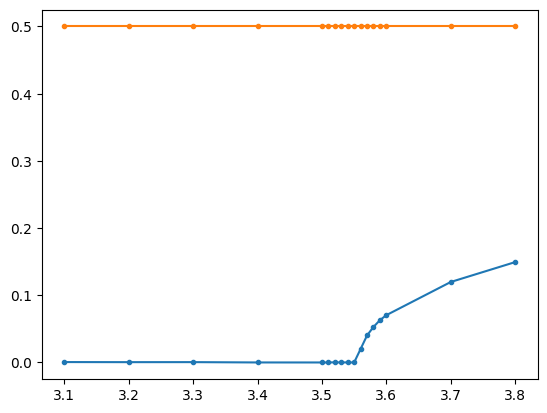

In [10]:
fig, ax = plt.subplots(1)
ax.plot(df['dV'], np.abs(df['mean_Sz']), '.-', c='C0')
ax.plot(df['dV'], np.abs(df['mean_fill']), '.-', c='C1')

correlation legnth =  158.64625635430824
computed Kc =  0.31801493678887066
naive bosonization Kc =  (0.6519374414908893+0j)


/tmp/ipykernel_3966581/3792002573.py:9: RuntimeWarning: divide by zero encountered in power
  plt.plot(0.07 * np.arange(distrange, dtype=float)**(-2), label=r"$\frac{1}{x^2}$ decay")


0.6908723080762551

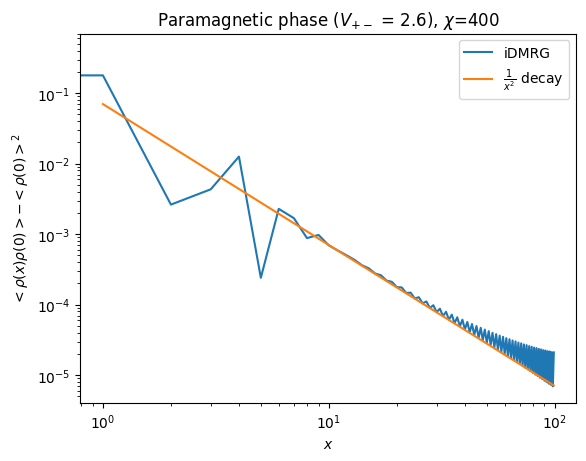

In [14]:
psipm = df[np.isclose(df['dV'], 3.1)]['psi'].iloc[0]
distrange = 100
print("correlation legnth = ", psipm.correlation_length2())
charge_corr_pm = observables.charge_corr(psipm, length=distrange, connected=True)
charge_corr_pm_w_sign =  psipm.correlation_function("Ntot", "Ntot", [0], distrange)[0] - (psipm.expectation_value("Ntot")[0])**2
calc_Kc = (np.pi / 2.0) * np.sum(charge_corr_pm_w_sign)
bosn_Kc ,bosn_Ks = compute_Luttinger_parameter(1, 0.1, 0.8, 0.8 + 2.60)
plt.plot(charge_corr_pm, label="iDMRG")
plt.plot(0.07 * np.arange(distrange, dtype=float)**(-2), label=r"$\frac{1}{x^2}$ decay")
plt.yscale('log')
plt.xscale('log')
plt.title(r"Paramagnetic phase ($V_{+-}$ = 2.6), $\chi$=400")
plt.ylabel(r"$<\rho(x) \rho(0)> - <\rho(0)>^2$")
plt.xlabel(r"$x$")
plt.yscale('log')
plt.xscale('log')
plt.legend()
print("computed Kc = ", calc_Kc)
print("naive bosonization Kc = ", bosn_Kc)
0.07 * np.pi**2

In [56]:
ft = np.array([np.sum(np.exp(2*np.pi*1j * np.arange(distrange) * kint / distrange) * charge_corr_pm_w_sign) for kint in np.arange(distrange)])
kvals = 2 * np.pi / distrange * np.arange(distrange)
grads = np.gradient(ft, kvals)
np.pi * grads[0]

np.complex128(0.3046003680238664-0.7640769434471203j)

/tmp/ipykernel_1833578/717278757.py:3: RuntimeWarning: divide by zero encountered in power
  plt.plot(0.06 * (np.arange(distrange,dtype=float)[0:])**-2, label=r"$\frac{1}{x^2}$ decay")


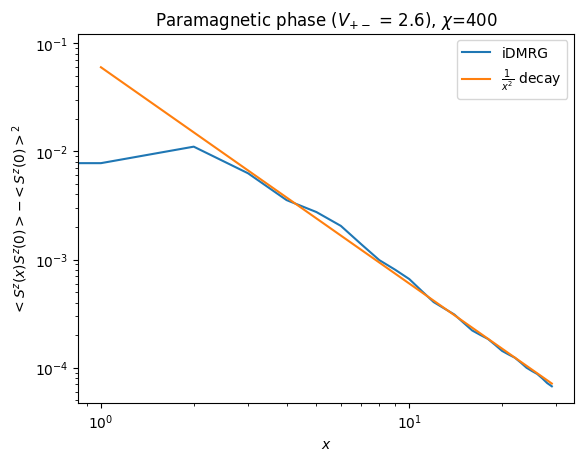

In [24]:
distrange = 30
plt.plot(observables.SzSz_corr(psipm, length=distrange, connected=True), label="iDMRG")
plt.plot(0.06 * (np.arange(distrange,dtype=float)[0:])**-2, label=r"$\frac{1}{x^2}$ decay")
plt.title(r"Paramagnetic phase ($V_{+-}$ = 2.6), $\chi$=400")
plt.ylabel(r"$<S^z(x) S^z(0)> - <S^z(0)>^2$")
plt.xlabel(r"$x$")
plt.yscale('log')
plt.xscale('log')
plt.legend()

In [138]:
psipm = df[np.isclose(df['dV'], 3.1)]['psi'].iloc[0]
psicrit = df[np.isclose(df['dV'], 3.55)]['psi'].iloc[0]
psifm= df[np.isclose(df['dV'], 3.7)]['psi'].iloc[0]
distrange = 1000
# fmspincorr = observables.SzSz_corr(psifm, length=distrange, connected=True)
# fmchargecorr = observables.charge_corr(psifm, length=distrange, connected=True)
electroncorr = observables.electron_corr(psicrit, length=distrange)
pmelectroncorr = observables.electron_corr(psipm, length=distrange)
fmelectroncorr = observables.electron_corr(psifm, length=distrange)

In [139]:
xicrit, xipm, xifm = psicrit.correlation_length2(), psipm.correlation_length2(), psifm.correlation_length2()
xicrit, xipm, xifm

(np.float64(213.08966442147272),
 np.float64(158.64625635431898),
 np.float64(46309507736455.54))

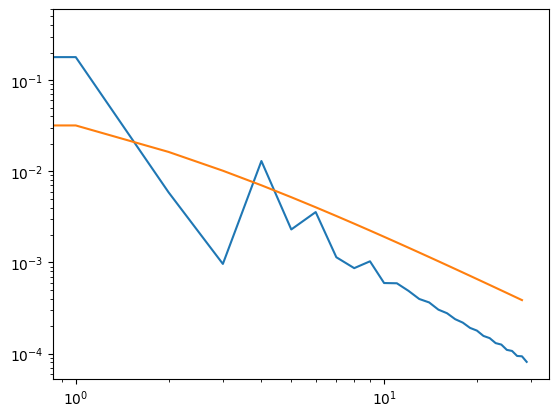

In [22]:
plt.plot(fmchargecorr)
plt.plot(0.1 * (np.arange(distrange, dtype=float)[1:]**(-1.65)))
plt.yscale('log')
plt.xscale('log')

(1e-10, 1)

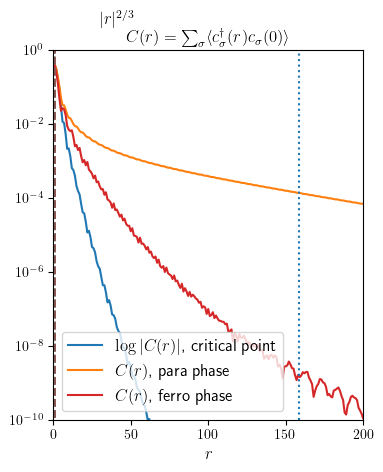

In [137]:
fig, ax = plt.subplots()
fig.set_figwidth(4)
plt.rcParams['text.usetex'] = True
ax.plot(np.abs((observables.denoise_rolling(np.abs(electroncorr), window=4))), label=r'$\log|C(r)|$, critical point')
ax.plot(np.abs((observables.denoise_rolling(np.abs(pmelectroncorr), window=4))), label=r'$C(r)$, para phase')

ax.plot(1.5*np.arange(distrange)**(0.71), ls='--')
ax.text(30, 5, r'$|r|^{2/3}$', fontsize=12)
# plt.plot(0.025 * (np.arange(distrange)[1:])**-1.65)


ax.plot(np.abs((observables.denoise_rolling(np.abs(fmelectroncorr), window=4))), label=r'$C(r)$, ferro phase')
ax.plot(1.3*np.arange(distrange)**(0.55), ls='--')

ax.plot(1.5*np.arange(distrange)**(1./4.), ls='--')
ax.legend(loc='lower left', fontsize=12)
ax.set_xlabel(r'$r$', fontsize=12)
ax.set_title(r"$C(r) = \sum_{\sigma}\langle c^\dagger_\sigma(r) c_\sigma(0) \rangle$", fontsize=12)

ax.axvline(xicrit ,ls=':')
ax.axvline(xipm ,ls=':')
# ax.axvline(xifm ,ls=':')

ax.set_yscale('log')
# ax.set_xscale('log')
ax.set_xlim(0,200)
ax.set_ylim(1e-10, 1)
# fig.savefig('showstretchedExp.pdf', bbox_inches='tight')

In [77]:
pm_pmcorr = observables.SpSm_corr(psipm, distrange)
crit_pmcorr = observables.SpSm_corr(psicrit, distrange)

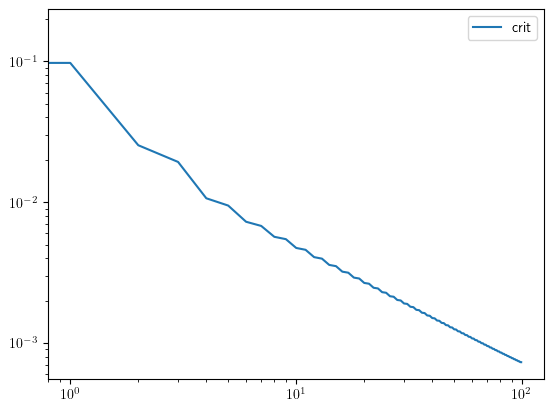

In [87]:
xvals = np.arange(distrange)
# plt.plot(xvals, observables.denoise_rolling(np.abs(pm_pmcorr), window=2), label='para')
plt.plot(xvals, observables.denoise_rolling(np.abs(crit_pmcorr), window=2), label='crit')
# plt.plot(xvals, xvals**)
plt.yscale('log')
plt.xscale('log')
plt.legend()

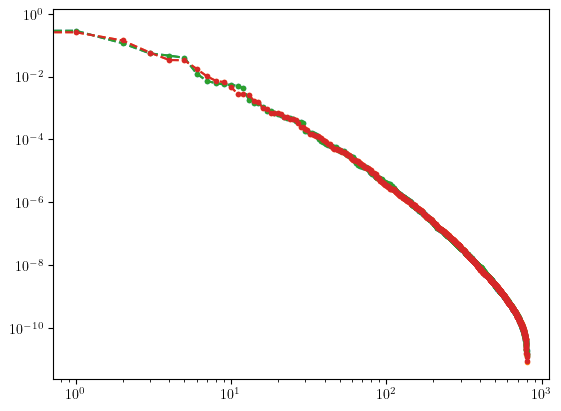

In [145]:
for i in [0,1,2,3]:
    plt.loglog(np.exp(-np.array(psicrit.entanglement_spectrum()))[i], ls='--', marker='.')

In [152]:
evspm,   _ = TransferMatrix(psipm, psipm).eigenvectors(100)
evscrit, _ = TransferMatrix(psicrit, psicrit).eigenvectors(100)
evsfm,   _ = TransferMatrix(psifm, psifm).eigenvectors(100)  

[-0.01859635+0.j -0.01661942+0.j -0.00368888+0.j -0.01563278+0.j
 -0.01271952+0.j -0.00852898+0.j -0.00329779+0.j -0.00883236+0.j
 -0.01376705+0.j -0.00565652+0.j -0.01040469+0.j -0.01351398+0.j
 -0.00677772+0.j -0.00367695+0.j -0.00166728+0.j -0.00794442+0.j
 -0.00840334+0.j -0.002525  +0.j -0.00697783+0.j -0.01181996+0.j]


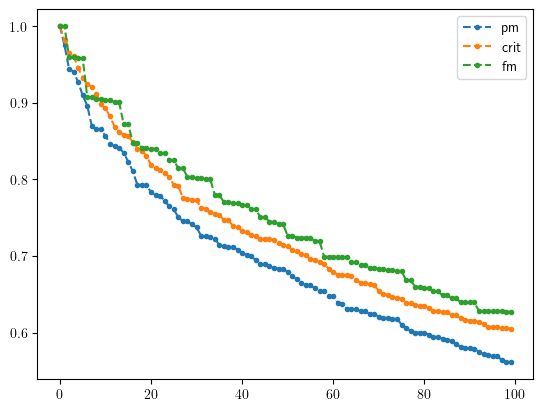

In [169]:
plt.plot(np.arange(100), np.abs(evspm), ls='--', marker='.', label='pm')
plt.plot(np.arange(100), np.abs(evscrit), ls='--', marker='.', label='crit')
plt.plot(np.arange(100), np.abs(evsfm), ls='--', marker='.', label='fm')
plt.legend()
print(np.diff(evscrit)[0:20])